In [1]:
import pandas as pd
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
from wcorr import WeightedCorr

This file aims to analyze two separate relationships between the columns V242536 (American Identity) and V241156 (Feeling Thermometer: Kamala Harris), and columns V242536 (American Identity) and V241157 (Feeling Thermometer: Donald Trump). These two relationships primarily seek to analyze the correlation and impact of nationalism and patriotism in an individual to their preferential candidate. 

Because the column associated with American Identity was conducted as a post election survey, the column V240002c (Pre/Post Interview Completion Status) is also utilized to specifically filter for interviewees who filled out the post election portion of the survey. In addition, the column V240108b, which contains the sampling weights for each row, is also important for the purposes of this analysis when performing the statistical tests.

In [2]:
# Loading in the dataset and associated columns
anes2024_csv = "../../../dataset/data_2024/anes_timeseries_2024_csv_20250808.csv"
df = pd.read_csv(anes2024_csv)

df_filtered = df[["V240002c", "V242536", "V241156", "V241157", "V240108b"]]

df_filtered

/var/folders/g2/vvdf2tl51t998r9wwxwrcdym0000gn/T/ipykernel_81197/2275628996.py:3: DtypeWarning: Columns (0: V240101a, 1: V240101c, 2: V240101d, 3: V240103a, 4: V240103c, 5: V240103d, 6: V240104a, 7: V240104c, 8: V240104d, 9: V240105a, 10: V240105c, 11: V240105d, 12: V240106a, 13: V240106c, 14: V240106d, 15: V240108a, 16: V240108c, 17: V240108d, 18: V243002, 19: V243003, 20: V243004, 21: V243005, 22: V243006, 23: V243009, 24: V243050, 25: V243051, 26: V243052, 27: V243053, 28: V243056, 29: V243057, 30: V243058) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(anes2024_csv)


,V240002c,V242536,V241156,V241157,V240108b
0,2,1,0,100,.780974621163524
1,2,3,50,50,2.50707498962934
2,2,5,90,0,.814400897948447
3,2,2,50,70,.263490124186044
4,2,4,5,60,.216673241876399
...,...,...,...,...,...
5516,1,-6,50,50,
5517,2,3,85,0,1.90730910362323
5518,1,-6,50,50,
5519,2,3,90,0,2.56436072555069


In [3]:
# Improving readability of the filtered dataframe by renaming the columns first
df_filtered = df_filtered.rename(columns={'V240002c': 'Completed Post Survey', 'V242536': 'American Identity', 
                                    'V241156': 'Harris Feeling Thermometer', 'V241157': 'Trump Feeling Thermometer', 'V240108b': 'Weights'})
df_filtered

# Filtering rows of the dataframe so that only those who completed the post election survey are considered
df_filtered = df_filtered[df_filtered['Completed Post Survey'] == 2]
df_filtered

# Filtering rows of the dataframe with invalid American Identity values are removed
# The guide states that any negative value indicates the interviewee did not complete this question for a variety of reasons, 
# thus those specific rows will not be considered.
df_filtered = df_filtered[df_filtered['American Identity'].isin([1, 2, 3, 4, 5])]
df_filtered

# Continuing the filter through the feeling thermometers, removing any invalid rows
# Similarly to the previous filtering, the guide states that any negative values represent unusable data and will thus be removed.
df_filtered = df_filtered[(df_filtered['Harris Feeling Thermometer'] >= 0) & (df_filtered['Trump Feeling Thermometer'] >= 0)]
df_filtered

# We can observe through the guide that the american identity values are actually originally in reverse order, with 1 being the strongest 
# identity and 5 being the weakest. For the sake of consistency for the later plots and statistical testing, it will be corrected here so that
# the higher the identity value, the more strongly the interviewee feels about their american identity.
df_filtered['American Identity'] = 6 - df_filtered['American Identity']
df_filtered

# Filling in empty weight values with 0 weight
df_filtered["Weights"] = df_filtered["Weights"].apply(lambda x: 0 if x == ' ' or x == '' else x)
df_filtered["Weights"] = df_filtered["Weights"].astype(float)
df_filtered

# Creating two separate dataframes for both Harris and Trump
df_harris = df_filtered[['American Identity', 'Harris Feeling Thermometer', 'Weights']]
df_trump = df_filtered[['American Identity', 'Trump Feeling Thermometer', 'Weights']]
display(df_harris)
display(df_trump)

,American Identity,Harris Feeling Thermometer,Weights
0,5,0,0.780975
1,3,50,2.507075
2,1,90,0.814401
3,4,50,0.263490
4,2,5,0.216673
...,...,...,...
5514,4,48,0.596674
5515,5,100,0.094869
5517,3,85,1.907309
5519,3,90,2.564361


,American Identity,Trump Feeling Thermometer,Weights
0,5,100,0.780975
1,3,50,2.507075
2,1,0,0.814401
3,4,70,0.263490
4,2,60,0.216673
...,...,...,...
5514,4,48,0.596674
5515,5,0,0.094869
5517,3,0,1.907309
5519,3,0,2.564361


Now that we have cleaned our dataset, we can move to plot our data in order to draw some initial conclusions and observations about the relationship between American Identity and an individual's preference for Harris/Trump as presidential candidates.

We will use boxplots to graph the distributions of the feeling thermometer scores in accordance to the american identity of the interviewees.

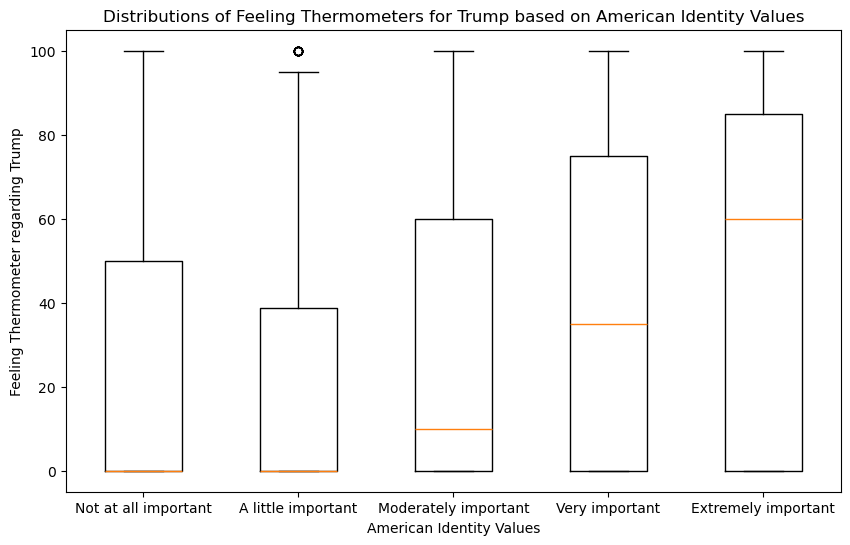

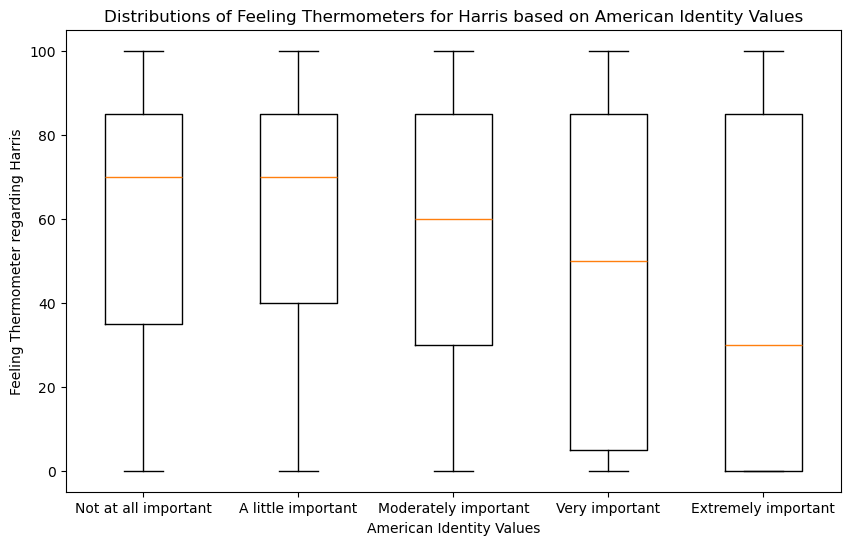

In [4]:
# Split apart the two dataframes even further so that we can map the distributions between identity scores
df_trump_1 = df_trump[df_trump['American Identity'] == 1]
df_trump_2 = df_trump[df_trump['American Identity'] == 2]
df_trump_3 = df_trump[df_trump['American Identity'] == 3]
df_trump_4 = df_trump[df_trump['American Identity'] == 4]
df_trump_5 = df_trump[df_trump['American Identity'] == 5]

df_harris_1 = df_harris[df_harris['American Identity'] == 1]
df_harris_2 = df_harris[df_harris['American Identity'] == 2]
df_harris_3 = df_harris[df_harris['American Identity'] == 3]
df_harris_4 = df_harris[df_harris['American Identity'] == 4]
df_harris_5 = df_harris[df_harris['American Identity'] == 5]

# Plot the newly formed dataframes into separate boxplots
plt.figure(figsize=(10, 6))
plt.boxplot([df_trump_1['Trump Feeling Thermometer'], df_trump_2['Trump Feeling Thermometer'], df_trump_3['Trump Feeling Thermometer'], df_trump_4['Trump Feeling Thermometer'], df_trump_5['Trump Feeling Thermometer']], 
            tick_labels=['Not at all important', 'A little important', 'Moderately important', 'Very important', 'Extremely important'])
plt.ylabel('Feeling Thermometer regarding Trump')
plt.xlabel('American Identity Values')
plt.title('Distributions of Feeling Thermometers for Trump based on American Identity Values')
plt.show()

plt.figure(figsize=(10, 6))
plt.boxplot([df_harris_1['Harris Feeling Thermometer'], df_harris_2['Harris Feeling Thermometer'], df_harris_3['Harris Feeling Thermometer'], df_harris_4['Harris Feeling Thermometer'], df_harris_5['Harris Feeling Thermometer']], 
            tick_labels=['Not at all important', 'A little important', 'Moderately important', 'Very important', 'Extremely important'])
plt.ylabel('Feeling Thermometer regarding Harris')
plt.xlabel('American Identity Values')
plt.title('Distributions of Feeling Thermometers for Harris based on American Identity Values')
plt.show()

In addition to these graphs, we will now perform a statistical test on the corresponding dataframes before coming to a more concrete conclusion on the relationship between an individual's American Identity and their preference for both Harris and Trump as presidential candidates.

I have chosen to use a Spearman's Correlation Coefficient test, since we have ordinal data, that being the ranking of american identity on a scale from 1 to 5, as well as a continuous variable of the feeling thermometers for both Harris and Trump. Additionally, the Spearman's Correlation Coefficient test does not depend on normality, and normality can not be assumed when it comes to the provided data for the feeling thermometers.

Hypothesis Tests: <br>
H0 = The American Identity of an individual has no effect on their feeling thermometer score for Trump/Harris <br>
HA = The American Identity of an individual has an effect on their feeling thermometer score for Trump/Harris

In [10]:
# Performing the weighted spearman's correlation coefficient tests
trump_coef = WeightedCorr(xyw=df_trump[['American Identity', 'Trump Feeling Thermometer', 'Weights']])(method='spearman')
harris_coef = WeightedCorr(xyw=df_harris[['American Identity', 'Harris Feeling Thermometer', 'Weights']])(method='spearman')

trump_unweight = sp.stats.spearmanr(df_trump['American Identity'], df_trump['Trump Feeling Thermometer'])
harris_unweight = sp.stats.spearmanr(df_harris['American Identity'], df_harris['Harris Feeling Thermometer'])

display(trump_coef)
display(harris_coef)

display(trump_unweight.pvalue)
display(harris_unweight.pvalue)

np.float64(0.2918632889626895)

np.float64(-0.20401859865017727)

np.float64(3.7270579199979215e-86)

np.float64(3.598337401231189e-43)

There are many observations that can be noted from both the statistical test and graphical plot that was created earlier regarding the relationship between american identity and the feeling thermometers of Trump and Harris.

Firstly, we can observe that our two p-values are incredibly small, much smaller than the accepted value of alpha = 0.05, we can thus reject our null hypotheses and state that the american identity of an individual has a statistical signficance on their feeling thermometer scores of Trump and Harris.

Additionally, it can be observed that there is a general positive trend in regards to an individual's american identity and their opinion of Trump. As noted by both the box plots and the spearman coefficient being greater than 0, the more an individual considers their american identity to be important to them, the higher they regard Trump as a political candidate. Inversely, a generally negative trend can be noted with american identity and the feeling thermometer score of Harris as a political candidate from the boxplots and correlation coefficient. This is seen with the median of the feeling thermometer generally decreasing as american identity grows in importance between the boxplots, as well as the corresponding spearman coefficient being less than 0.

There are still some issues that need to be discussed from these initial tests, namely the overall strength of the relationship presented for both Trump and Harris. As noted by the correlation coefficient especially, the values 0.29 and -0.20 suggest that the relationship between american identity and the feeling thermometer scores is not necessarily very strong, and in general can be stated to be moderate to weak. This suggests that while a relationship certainly does seem to exist, it might not be as prevalent as one may think and thus should be considered when performing analysis on the two variables.

These limitations can also be noticed in the boxplots as well. In every single boxplot in both graphs, one can note the clear maximum and minimum values still being from 100 to 0 respectively, thus implying that there still exist non outlier individuals in all the groups who vote out of the norm of the median. Additionally, there is a noticable "floor" effect with the Trump boxplots and a "ceiling" effect with the Harris ones, that is to say that the lower and upper quartile respectively do not seem to change as the american identity becomes increasingly important. This supports the corrleation coefficients being on the weaker side, since there are still those who vote weakly/strongly about the candidate across all the groups, thus decreasing the overall strength of the relationship between the two variables.

That being said, the indication that a relationship does exist means that these two variables are still worth analyzing and looking into for any future analysis that may come from this project.